# USEPA 2018-2019 Model Evaluation
The purpose of this Jupyter notebook is to evaluate the selected model (GBR) for the EPA 2018-19 NRSA dataset using **only remotely-sensed data.** This notebook evaluates model accuracy, XAI, and geographic visualizations.

Emma Reilly Oare

In [1]:
# Read in libs
import os
import warnings
import pandas as pd
import numpy as np 
import joblib
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer 
from sklearn.inspection import permutation_importance
import shap

# Suppress warnings
warnings.filterwarnings("ignore")

## Step 1. Import Dataset

In [2]:
# Define base directory
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "../.."))

In [3]:
# Define paths
mdl_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "trained_gbr_model.pkl")
train_test_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "train_test_sets.pkl")

# Load train/test sets and model
x_train, x_test, y_train, y_test = joblib.load(train_test_path)
gbr_model = joblib.load(mdl_path)

## Step 2. Present metrics

In [5]:
# Read in metric dataframe
metric_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "epa_1819_metrics.xlsx")
metric_df = pd.read_excel(metric_path)

In [11]:
# Display metrics
metric_df.iloc[1,:]

Model        GBR
CV RMSE     16.9
CV MAE     13.69
CV R2       0.49
CV NSE      0.49
Name: 1, dtype: object

## Step 3. Model Evaluation

### Step 3a. Model Predictions vs. Observed

In [12]:
# Create predictions
gbr_pred = gbr_model.predict(x_test)
# Reshape y_test to numpy array for residual calculations
y_test_np = y_test.to_numpy().reshape(-1)

# Calculate_residuals
gbr_residuals = y_test_np - gbr_pred.flatten()

# Display residual shape
gbr_residuals.shape

(193,)

In [13]:
# Print residual statistics for test set only
print("The maximum residual is", round(np.abs(gbr_residuals).max(), 4), "% embeddedness.")
print("The median residual is", round(np.median(np.abs(gbr_residuals)), 4), "% embeddedness.")
print("The minimum residual is", round(np.abs(gbr_residuals).min(), 4), "% embeddedness.")

The maximum residual is 42.9104 % embeddedness.
The median residual is 10.4184 % embeddedness.
The minimum residual is 0.0429 % embeddedness.


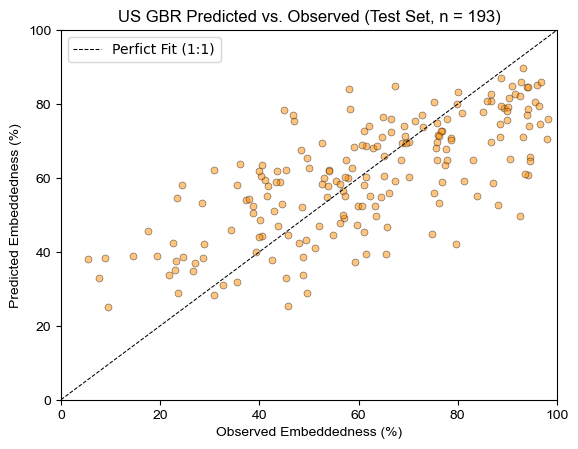

In [15]:
# Plot predictions vs observed
plt.scatter(y_test,
            gbr_pred,
            color = 'darkorange',
            alpha = 0.5,
            s = 25,
            edgecolors = 'black',
            linewidths = 0.5)
plt.xlabel('Observed Embeddedness (%)', fontname = 'Arial')
plt.ylabel('Predicted Embeddedness (%)', fontname = 'Arial')
plt.title(f'US GBR Predicted vs. Observed (Test Set, n = {gbr_residuals.shape[0]})', fontname = 'Arial')
plt.ylim([0, 100])
plt.xlim([0, 100])
plt.plot([0, 100], [0, 100],
         color = 'k',
         linestyle = '--',
         linewidth = 0.75,
        label = 'Perfict Fit (1:1)')
plt.legend()
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")

# Save to results folder
predict_obs_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures", "us_gbr_predict_vs_obs_testset.png")
plt.savefig(predict_obs_path, dpi = 300)

# Show plot
plt.show()

### Step 3b. Residual Scatter Plot

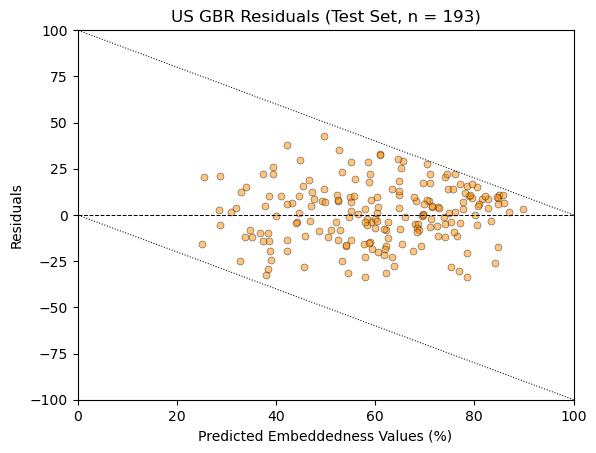

In [18]:
# Plot residuals
plt.scatter(gbr_pred,
            gbr_residuals,
            color = 'darkorange',
            s = 25,
            alpha = 0.5,
            edgecolors = 'black',
            linewidths = 0.5)
plt.xlabel('Predicted Embeddedness Values (%)')
plt.ylabel('Residuals')
plt.title(f'US GBR Residuals (Test Set, n = {gbr_residuals.shape[0]})')
plt.ylim([-100, 100])
plt.xlim([0, 100])

# Plot perfect prediction line
plt.axhline(y = 0,
            color = 'k',
            linestyle = '--',
           linewidth = 0.75)

# Plot boundaries
plt.plot([100, 0], [0, 100],
         color = 'k',
         linestyle = ':',
         linewidth = 0.75)
plt.plot([100, 0], [-100, 0],
         color = 'k',
         linestyle = ':',
         linewidth = 0.75)

# Save to results folder
resid_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures", "us_gbr_residuals.png")
plt.savefig(resid_path, dpi = 300)

# Show plot
plt.show()

### Step 3c. Plot Residual Histogram
We want to ensure we are having normally distributed residuals from the model.

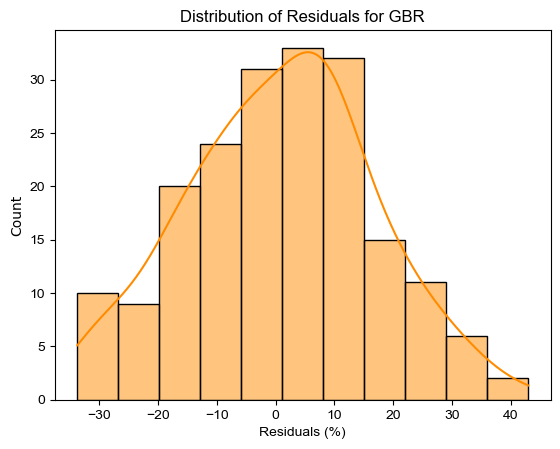

In [19]:
# Plot residuals distribution to check for Gaussian distribution
sns.histplot(gbr_residuals, kde=True, color = 'darkorange', alpha = 0.5)
plt.xlabel('Residuals (%)', fontname = 'Arial')
plt.title('Distribution of Residuals for GBR', fontname = 'Arial')
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")

# Save to results folder
resid_hist_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures", "us_gbr_residual_hist.png")
plt.savefig(resid_hist_path, dpi = 300)

# Show plot
plt.show()

## Step 4. Explainability

### Step 4a. Feature Importance

In [20]:
# Calculate importances
importances = gbr_model.feature_importances_
indices = np.argsort(importances)[::-1] 
feature_names = x_test.columns

# Display importances
importances

array([0.0545331 , 0.05219297, 0.20449411, 0.04881606, 0.06394643,
       0.07971159, 0.05234252, 0.06295342, 0.05871946, 0.04368075,
       0.0551657 , 0.07128628, 0.11263134, 0.00215665, 0.00941405,
       0.01823902, 0.00512265, 0.0012236 , 0.00124518, 0.00212511])

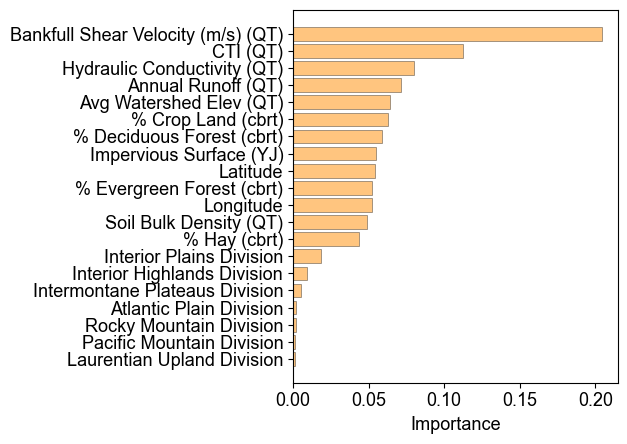

In [21]:
# plt.title("Impurity-Based Feature Importances", fontname = 'Arial')
plt.figure(figsize=(6, 4.5))
plt.barh(range(len(importances)), 
        importances[indices], 
        align='center', 
        color = 'darkorange',
        edgecolor = 'black',
         alpha = 0.5,
        linewidth = 0.5)
plt.gca().invert_yaxis()
plt.yticks(range(len(importances)), [feature_names[i] for i in indices], rotation=0)
plt.xlabel("Importance", fontname = 'Arial', fontsize=13)
plt.tight_layout()
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
    tick.set_fontsize(13)
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
    tick.set_fontsize(13)

# Save to results folder
feat_imp_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures", "us_impurity_feature_importances.png")
plt.savefig(feat_imp_path, dpi = 300, bbox_inches = 'tight')

# Plot bar plots
plt.show()

#### Permutation Importance
Permutaton importance measures the increase in predicted error of the model after we permuted the feature's values. Permuting is the rearrangement of features. We measure the importance of a feature by calculating the increase in the model's prediction error after shuffling. A feature is “important” if shuffling its values increases the model error, because in this case the model relied on the feature for the prediction.

<br> Explanation from https://christophm.github.io/interpretable-ml-book/feature-importance.html

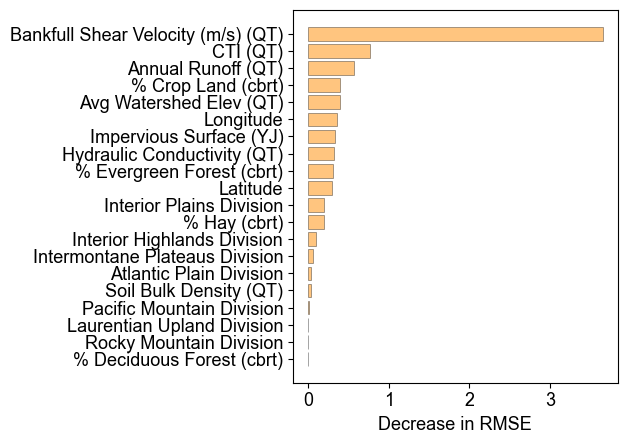

In [22]:
# Calculate permutation importances 
rmse_scorer = make_scorer(lambda y_true, gbr_pred: -np.sqrt(mean_squared_error(y_true, gbr_pred)))
result = permutation_importance(gbr_model, x_test, y_test, 
                                scoring=rmse_scorer, 
                                random_state = 42, 
                                n_repeats = 20)

# Create df for results
perm_importance_df = pd.DataFrame({'Feature': x_test.columns.values.tolist(),
                                'Importance': result.importances_mean,
                                'Std': result.importances_std}).sort_values(by='Importance', ascending=True)

# Plot figure
plt.figure(figsize=(6, 4.5))
plt.barh(perm_importance_df['Feature'], 
         perm_importance_df['Importance'], 
         color = 'darkorange',
         alpha = 0.5,
        edgecolor = 'k',
        linewidth =  0.5)
plt.xlabel('Decrease in RMSE', fontname = 'Arial', fontsize=13)
# plt.title('Permutation Feature Importance', fontname = 'Arial')
plt.tight_layout()
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
    tick.set_fontsize(13)
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
    tick.set_fontsize(13)

# Save figure to results folder
perm_imp_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures", "gbr_permutation_importances.png")
plt.savefig(perm_imp_path, dpi = 300, bbox_inches = 'tight')

# Show figure
plt.show()

### Step 4b. Global SHAP Plots

In [23]:
# Initialize the SHAP explainer
explainer = shap.TreeExplainer(gbr_model)
shap_values = explainer.shap_values(x_test)

#### Summary Plot (Bar)
The summary plot offers a comprehensive view of the most influential features in a model. It **ranks** features based on their effect on the model's predictions. The bar plot specifically presents each feature's average absolute SHAP values.

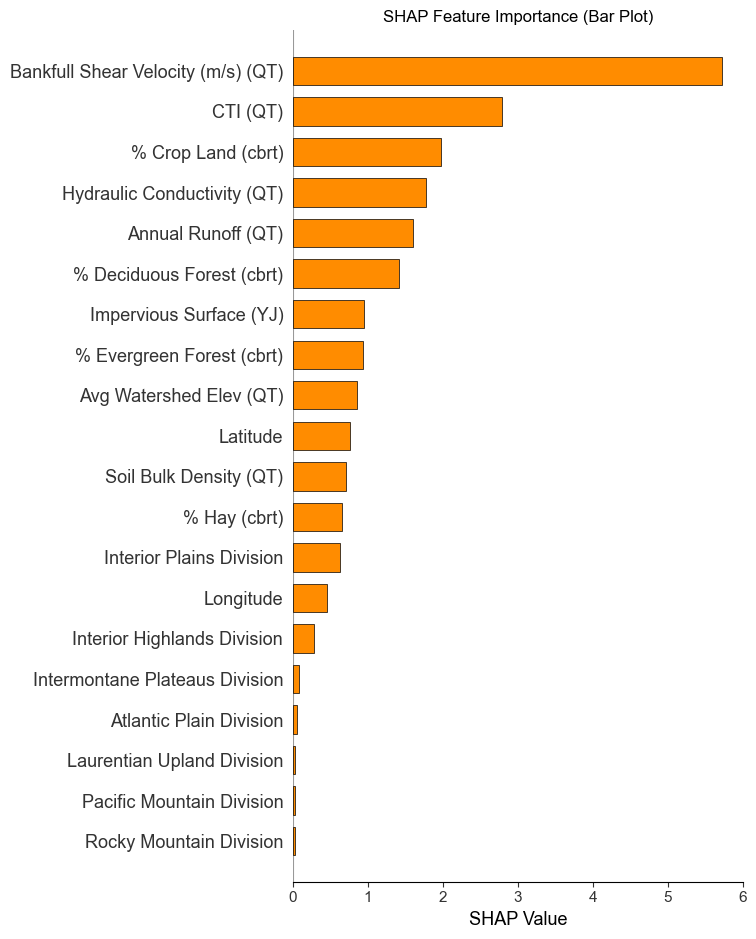

<Figure size 640x480 with 0 Axes>

In [24]:
# SHAP Summary Plot (Bar)
plt.title("SHAP Feature Importance (Bar Plot)", fontname = 'Arial')
shap.summary_plot(shap_values, x_test, 
                  plot_type = "bar", 
                  show = False,
                  color = 'darkorange',
                 alpha = 0.5)
plt.xlabel('SHAP Value', fontname = 'Arial')
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
for patch in ax.patches:
    patch.set_edgecolor('k')
    patch.set_linewidth(0.5)
plt.show()

# Save to results folder
shap_bar_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures", "us_shap_summary_bar.png")
plt.savefig(shap_bar_path, dpi = 300, bbox_inches = 'tight')

# Show plot
plt.show()

#### Summary Plot (Dot)
The dot summary plot is similar to the bar, but each dot represents a specific prediction. The feature value relates directly to the features actual numerical value, while it's location on the x-axis denotes its effect on the model prediction.

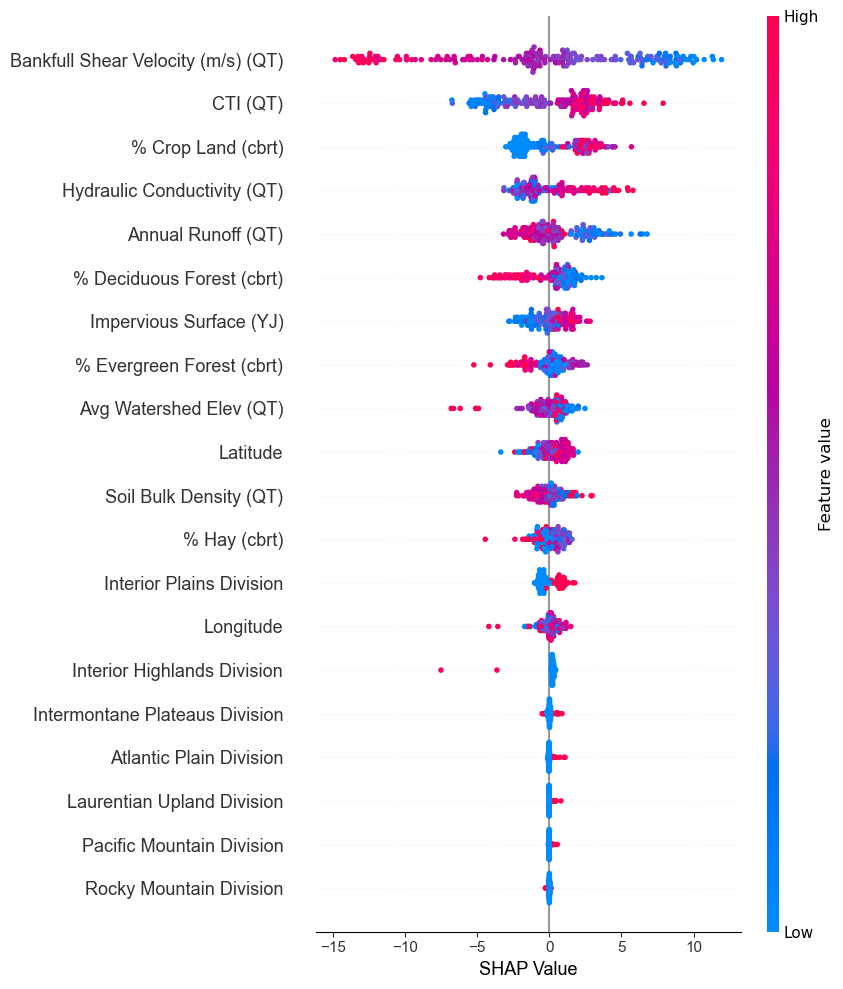

In [25]:
# SHAP Summary Plot Dot)
shap.summary_plot(shap_values, 
                  x_test, 
                  show = False,
                 plot_size=(9, 10))
plt.xlabel('SHAP Value', fontname='Arial')
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")

# Save to results folder
shap_dot_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures", "us_shap_summary_dot.png")
plt.savefig(shap_dot_path, dpi = 300, bbox_inches = 'tight')

# Show plot
plt.show()

#### Dependence Plots
We'll look at the top five features and use a dependence plot. These are still global (for the full test set).

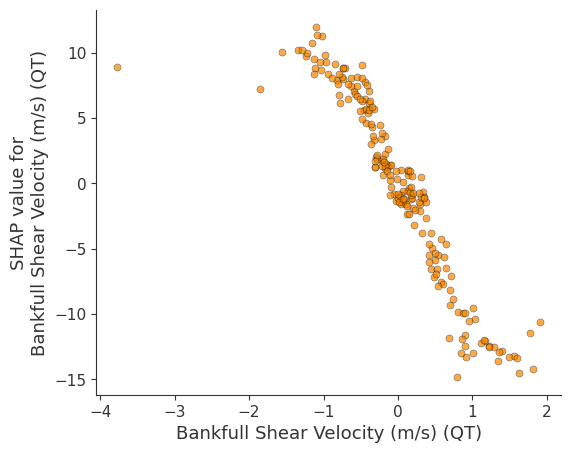

In [29]:
# Shows comparison to bankfull shear velocity
shap.dependence_plot('Bankfull Shear Velocity (m/s) (QT)', 
                     shap_values, 
                     x_test,
                    interaction_index = None,
                    color = 'darkorange',
                     alpha = 0.5,
                    show = False)

plt.scatter(plt.gca().collections[0].get_offsets()[:, 0],
            plt.gca().collections[0].get_offsets()[:, 1],
            edgecolors='k',
            linewidths=0.5,
            alpha = 0.5,
            s = 25,
            color='darkorange')
    
# Save to results folder
shap_soil_path = os.path.join(BASE_DIR, 'usepa_nrsa', "results", "figures", "shap_ustar_dependence.png")
plt.savefig(shap_soil_path, dpi = 300, bbox_inches = 'tight')

# Show plot
plt.show()

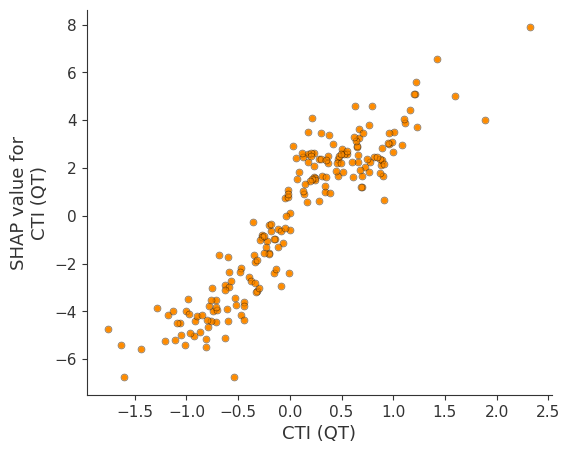

In [35]:
# Shows comparison to CTI
shap.dependence_plot('CTI (QT)', 
                     shap_values, 
                     x_test,
                    interaction_index = None,
                    color = 'darkorange',
                    show = False)

plt.scatter(plt.gca().collections[0].get_offsets()[:, 0],
            plt.gca().collections[0].get_offsets()[:, 1],
            edgecolors='k',
            linewidths=0.5,
            alpha = 0.5,
            s = 25,
            color='darkorange')

# Save to results folder
shap_cti_path = os.path.join(BASE_DIR, 'usepa_nrsa', "results", "figures", "shap_cti_dependence.png")
plt.savefig(shap_cti_path, dpi = 300, bbox_inches = 'tight')

# Show plot
plt.show()

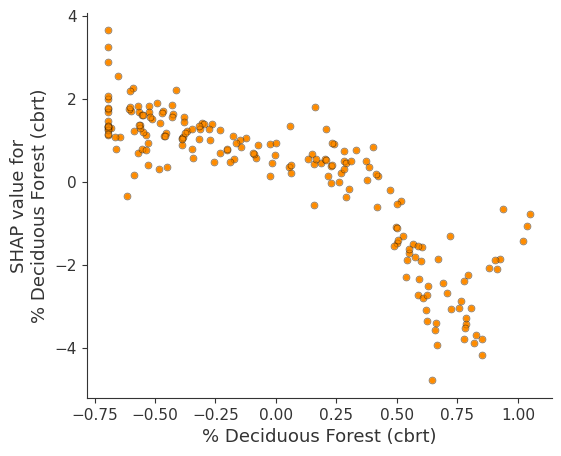

In [36]:
# Shows comparison to deciduous forest
shap.dependence_plot('% Deciduous Forest (cbrt)', 
                     shap_values, 
                     x_test,
                    interaction_index = None,
                    color = 'darkorange',
                    show = False)

plt.scatter(plt.gca().collections[0].get_offsets()[:, 0],
            plt.gca().collections[0].get_offsets()[:, 1],
            edgecolors='k',
            linewidths=0.5,
            alpha = 0.5,
            s = 25,
            color='darkorange')

# Save to results folder
shap_decid_path = os.path.join(BASE_DIR, 'usepa_nrsa', "results", "figures", "shap_decid_dependence.png")
plt.savefig(shap_decid_path, dpi = 300, bbox_inches = 'tight')

# Show plot
plt.show()

In [33]:
x_test.columns

Index(['Latitude', 'Longitude', 'Bankfull Shear Velocity (m/s) (QT)',
       'Soil Bulk Density (QT)', 'Avg Watershed Elev (QT)',
       'Hydraulic Conductivity (QT)', '% Evergreen Forest (cbrt)',
       '% Crop Land (cbrt)', '% Deciduous Forest (cbrt)', '% Hay (cbrt)',
       'Impervious Surface (YJ)', 'Annual Runoff (QT)', 'CTI (QT)',
       'Atlantic Plain Division', 'Interior Highlands Division',
       'Interior Plains Division', 'Intermontane Plateaus Division',
       'Laurentian Upland Division', 'Pacific Mountain Division',
       'Rocky Mountain Division'],
      dtype='object')

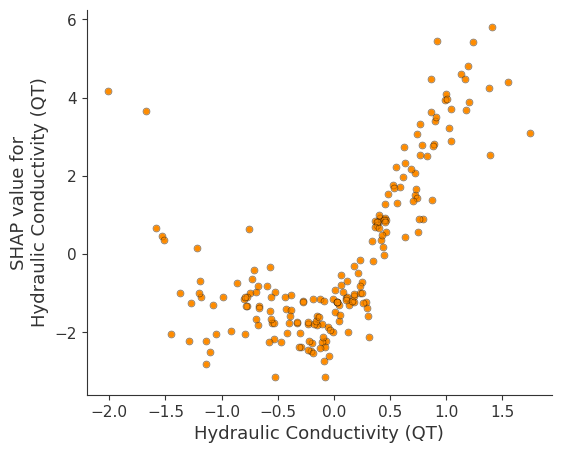

In [37]:
# Shows comparison to hydraulic conductivity
shap.dependence_plot('Hydraulic Conductivity (QT)', 
                     shap_values, 
                     x_test,
                    interaction_index = None,
                    color = 'darkorange',
                    show = False)

plt.scatter(plt.gca().collections[0].get_offsets()[:, 0],
            plt.gca().collections[0].get_offsets()[:, 1],
            edgecolors='k',
            linewidths=0.5,
            alpha = 0.5,
            s = 25,
            color='darkorange')

# Save to results folder
shap_soil_path = os.path.join(BASE_DIR, 'usepa_nrsa', "results", "figures", "shap_hydraulic_dependence.png")
plt.savefig(shap_soil_path, dpi = 300, bbox_inches = 'tight')

# Show plot
plt.show()

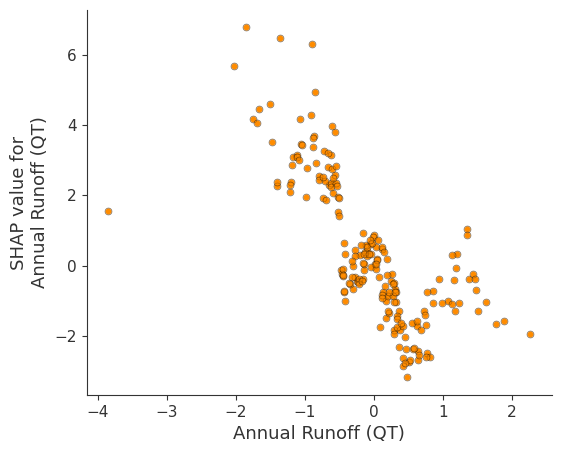

In [38]:
# Shows comparison to annual runoff
shap.dependence_plot('Annual Runoff (QT)', 
                     shap_values, 
                     x_test,
                    interaction_index = None,
                    color = 'darkorange',
                    show = False)

plt.scatter(plt.gca().collections[0].get_offsets()[:, 0],
            plt.gca().collections[0].get_offsets()[:, 1],
            edgecolors='k',
            linewidths=0.5,
            alpha = 0.5,
            s = 25,
            color='darkorange')

# Save to results folder
shap_soil_path = os.path.join(BASE_DIR, 'usepa_nrsa', "results", "figures", "shap_runoff_dependence.png")
plt.savefig(shap_soil_path, dpi = 300, bbox_inches = 'tight')

# Show plot
plt.show()

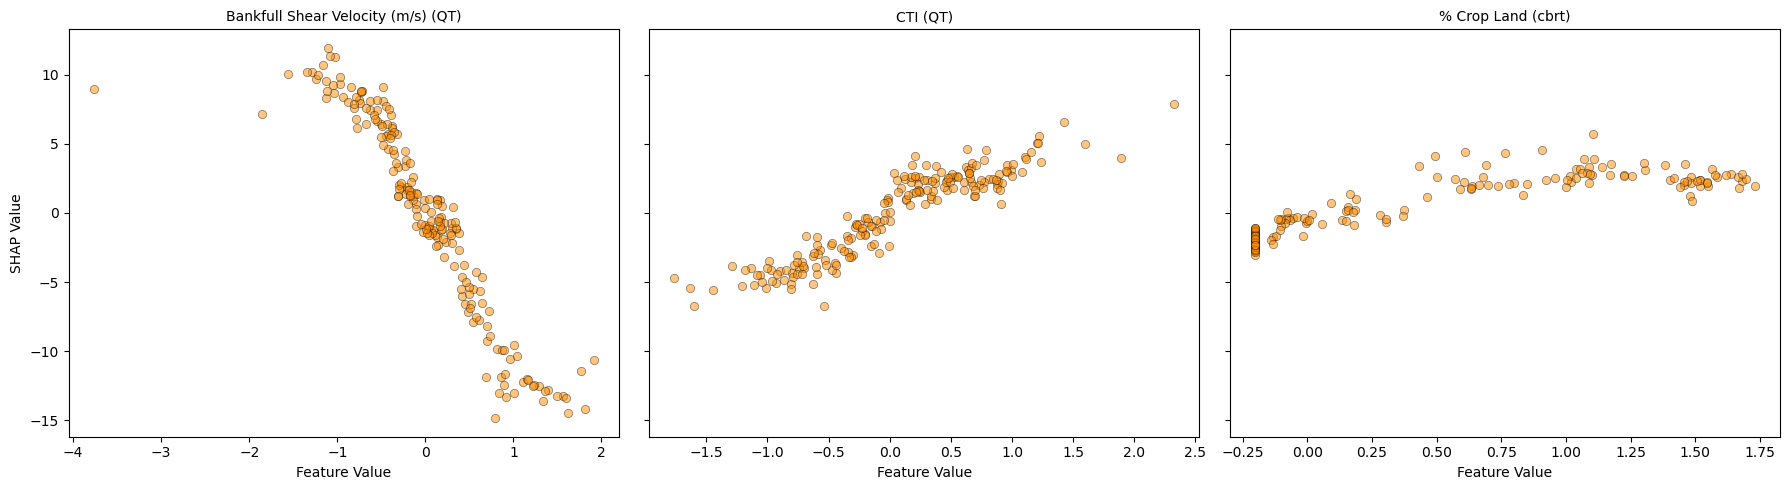

In [40]:
# List 3 feature names
features = [
    'Bankfull Shear Velocity (m/s) (QT)',
    'CTI (QT)',
    '% Crop Land (cbrt)'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, feature in enumerate(features):
    ax = axes[i]
    shap_vals = shap_values[:, x_test.columns.get_loc(feature)]
    x_vals = x_test[feature]
    ax.scatter(x_vals, shap_vals, alpha=0.5, edgecolors='k', linewidths=0.5, color='darkorange')
    ax.set_title(feature, fontsize=10)
    ax.set_xlabel('Feature Value')
    if i == 0:
        ax.set_ylabel('SHAP Value')
    plt.tight_layout()

# Save to results folder
shap_depend_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures", "shap_tri_dependence.png")
plt.savefig(shap_depend_path, dpi = 300, bbox_inches = 'tight')

plt.tight_layout()
plt.show()

### Step 4c. Local SHAP Plots
The local SHAP plots are for looking at specific predictions in the test set. We're going to look at:
- Two maximum positive residuals
- Two maximum negative residuals
- Two lowest residuals

In [41]:
# Create dataframe of predicted, observed, and residuals
results_df = pd.DataFrame({'Observed': y_test_np,
                           'Predicted': gbr_pred,
                           'Residual': gbr_residuals})

# Display dataframe
results_df

,Observed,Predicted,Residual
0,44.109091,58.927891,-14.818800
1,7.636364,32.817240,-25.180876
2,40.636364,63.394204,-22.757840
3,8.846154,38.334212,-29.488058
4,28.773585,42.254163,-13.480578
...,...,...,...
188,96.363636,79.447484,16.916153
189,14.545455,38.995656,-24.450202
190,66.545455,72.424615,-5.879161
191,66.636364,75.901014,-9.264650


In [42]:
# Sort to find key cases
max_positive_residual = results_df.nlargest(2, 'Residual')
max_negative_residual = results_df.nsmallest(2, 'Residual')
lowest_residuals = results_df.iloc[(results_df['Residual'] - 0).abs().argsort()[:2]]  # Most accurate predictions

# Combine all selected instances
selected_instances = pd.concat([max_positive_residual, max_negative_residual, lowest_residuals])

# Print results
selected_instances

,Observed,Predicted,Residual
97,92.545455,49.635015,42.910440
170,79.727273,42.156259,37.571014
182,24.333333,57.982436,-33.649103
150,45.018182,78.439565,-33.421383
147,69.545455,69.588358,-0.042904
69,79.818182,80.062493,-0.244312


#### Decision Plots
The SHAP decision plots will explain the deviation from an expected value by showing how each feature pushes the prediction up or down. The *expected_value* is the average model prediction. The *f(x)* is the final predicted value for the given instance.

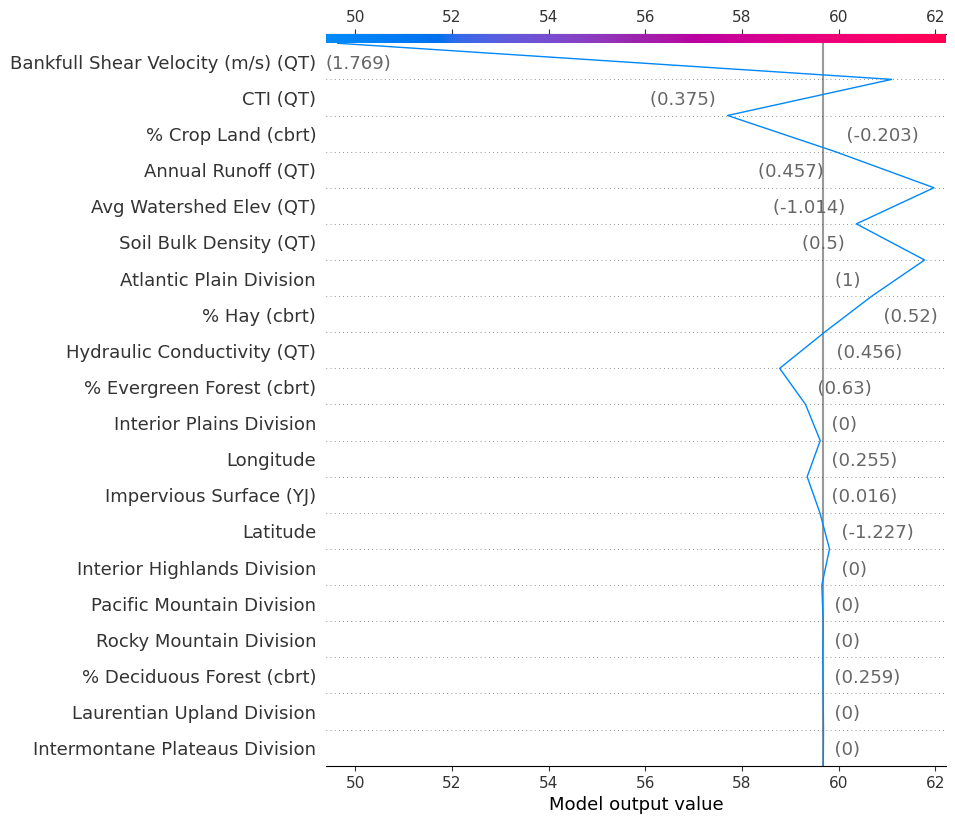

In [43]:
# Define index being used
index = selected_instances.iloc[0].name

# Plot decision plot
shap.decision_plot(explainer.expected_value,
                   shap_values[index],
                   x_test.iloc[index],
                  show = False)

# Save to results folder
shap_max_pos_1_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures", "shap_decision_max_pos_1.png")
plt.savefig(shap_max_pos_1_path, dpi = 300, bbox_inches = 'tight')

# Show plot
plt.show()

In [44]:
# Print information on sample above
print(f"Decision Plot for instance where observed Value = {(selected_instances.iloc[0, 0]):.2f}, Predicted Value = {selected_instances.iloc[0, 1]:.2f}, and Residual = {selected_instances.iloc[0, 2]:.2f}")

Decision Plot for instance where observed Value = 92.55, Predicted Value = 49.64, and Residual = 42.91


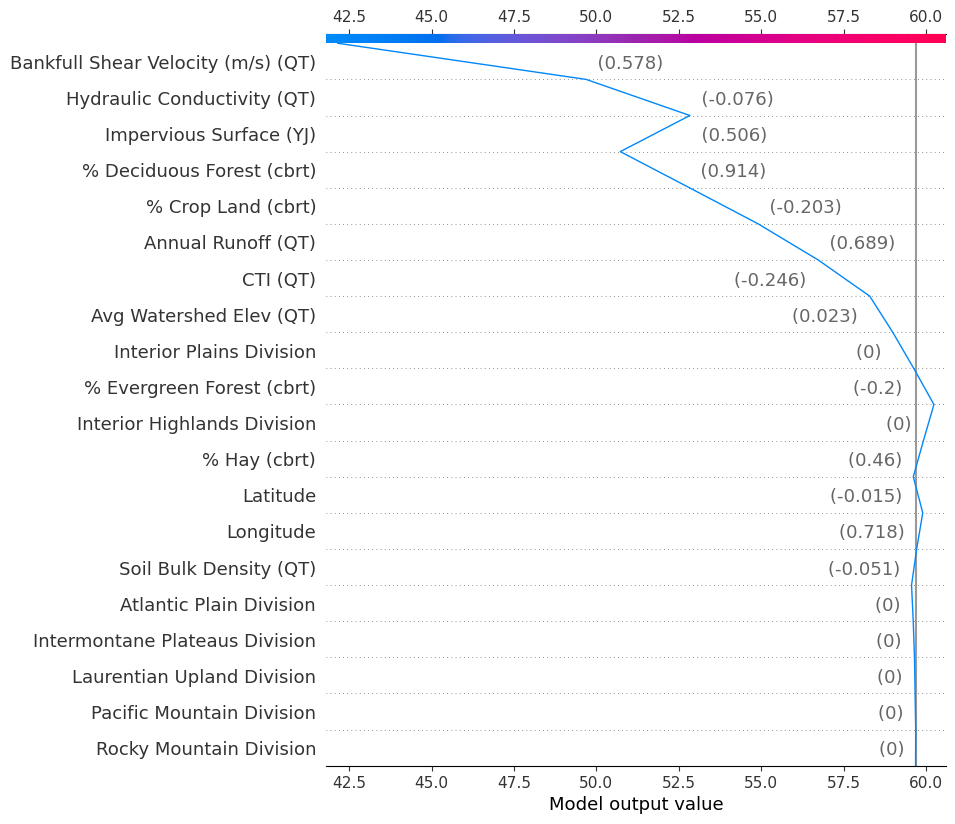

In [45]:
# Define index being used
index = selected_instances.iloc[1].name

# Plot decision plot
shap.decision_plot(explainer.expected_value,
                   shap_values[index],
                   x_test.iloc[index],
                  show = False)

# Save to results folder
shap_max_pos_2_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures", "shap_decision_max_pos_2.png")
plt.savefig(shap_max_pos_2_path, dpi = 300, bbox_inches = 'tight')

# Show plot
plt.show()

In [46]:
# Print information on sample above
print(f"Decision Plot for instance where observed Value = {(selected_instances.iloc[1, 0]):.2f}, Predicted Value = {selected_instances.iloc[1, 1]:.2f}, and Residual = {selected_instances.iloc[1, 2]:.2f}")

Decision Plot for instance where observed Value = 79.73, Predicted Value = 42.16, and Residual = 37.57


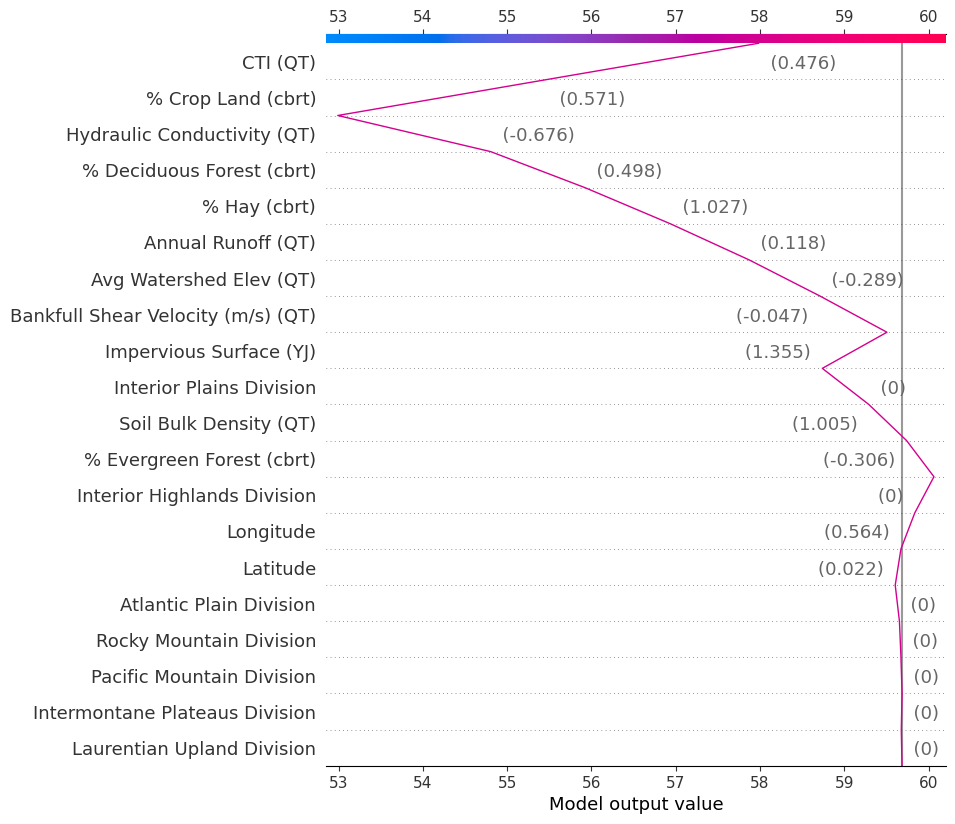

In [48]:
# Define index being used
index = selected_instances.iloc[2].name

# Plot decision plot
shap.decision_plot(explainer.expected_value,
                   shap_values[index],
                   x_test.iloc[index],
                  show = False)

# Save to results folder
shap_max_neg_1_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures", "shap_decision_max_neg_1.png")
plt.savefig(shap_max_neg_1_path, dpi = 300, bbox_inches = 'tight')

# Show plot
plt.show()

In [49]:
# Print information on sample above
print(f"Decision Plot for instance where observed Value = {(selected_instances.iloc[2, 0]):.2f}, Predicted Value = {selected_instances.iloc[2, 1]:.2f}, and Residual = {selected_instances.iloc[2, 2]:.2f}")

Decision Plot for instance where observed Value = 24.33, Predicted Value = 57.98, and Residual = -33.65


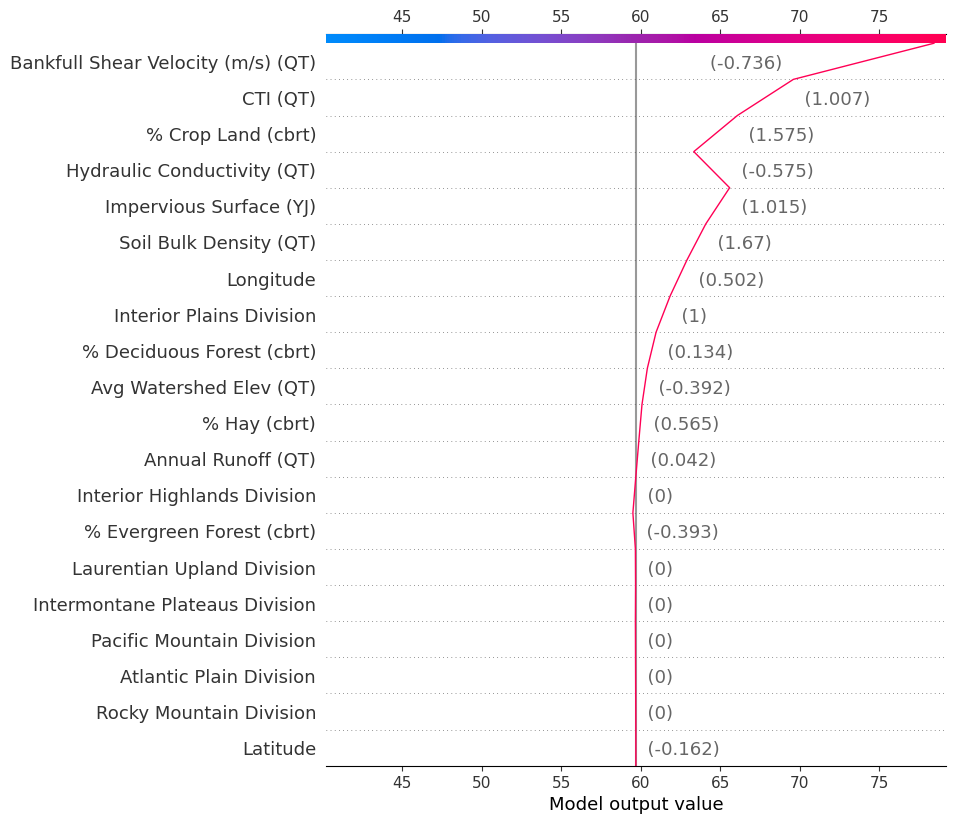

In [50]:
# Define index being used
index = selected_instances.iloc[3].name

# Plot decision plot
shap.decision_plot(explainer.expected_value,
                   shap_values[index],
                   x_test.iloc[index],
                  show = False)

# Save to results folder
shap_max_neg_2_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures", "shap_decision_max_neg_2.png")
plt.savefig(shap_max_neg_2_path, dpi = 300, bbox_inches = 'tight')

# Show plot
plt.show()

In [51]:
# Print information on sample above
print(f"Decision Plot for instance where observed Value = {(selected_instances.iloc[3, 0]):.2f}, Predicted Value = {selected_instances.iloc[3, 1]:.2f}, and Residual = {selected_instances.iloc[3, 2]:.2f}")

Decision Plot for instance where observed Value = 45.02, Predicted Value = 78.44, and Residual = -33.42


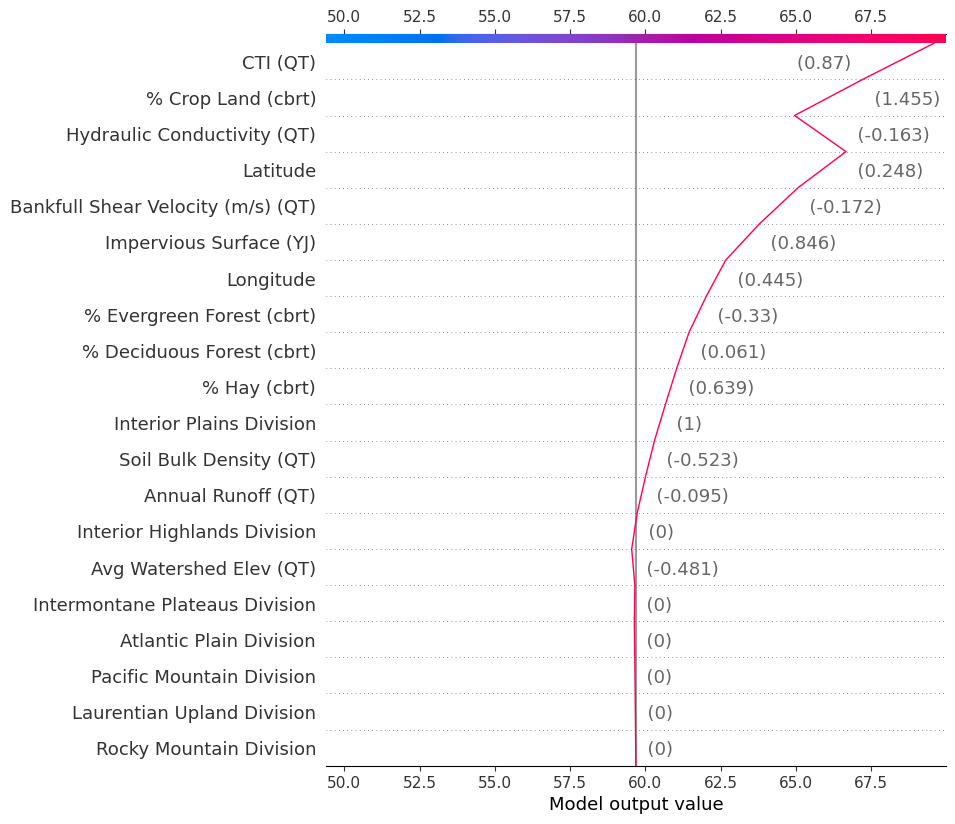

In [52]:
# Define index being used
index = selected_instances.iloc[4].name

# Plot decision plot
shap.decision_plot(explainer.expected_value,
                   shap_values[index],
                   x_test.iloc[index],
                  show = False)

# Save to results folder
shap_min_resid1_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures", "shap_decision_min_resid1.png")
plt.savefig(shap_min_resid1_path, dpi = 300, bbox_inches = 'tight')

# Show plot
plt.show()

In [53]:
# Print information on sample above
print(f"Decision Plot for instance where observed Value = {(selected_instances.iloc[4, 0]):.2f}, Predicted Value = {selected_instances.iloc[4, 1]:.2f}, and Residual = {selected_instances.iloc[4, 2]:.2f}")

Decision Plot for instance where observed Value = 69.55, Predicted Value = 69.59, and Residual = -0.04


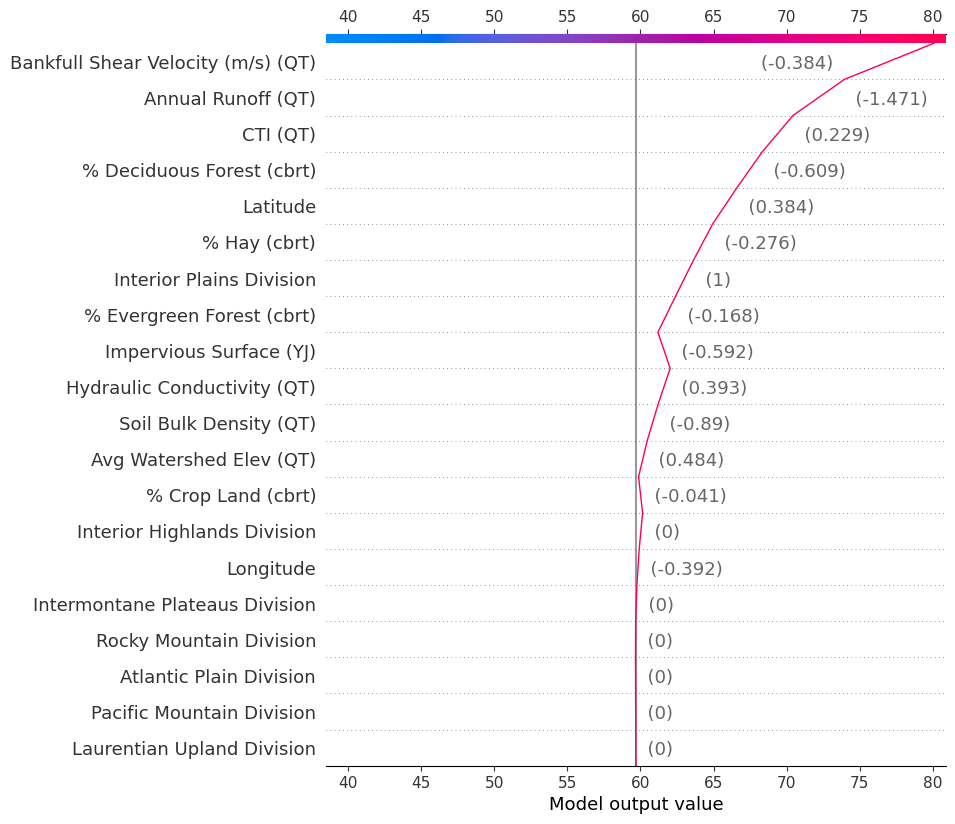

In [54]:
# Define index being used
index = selected_instances.iloc[5].name

# Plot decision plot
shap.decision_plot(explainer.expected_value,
                   shap_values[index],
                   x_test.iloc[index],
                  show = False)

# Save to results folder
shap_min_resid2_path = os.path.join(BASE_DIR, "usepa_nrsa", "results", "figures", "shap_decision_min_resid2.png")
plt.savefig(shap_min_resid2_path, dpi = 300, bbox_inches = 'tight')

# Show plot
plt.show()

In [55]:
# Print information on sample above
print(f"Decision Plot for instance where observed Value = {(selected_instances.iloc[5, 0]):.2f}, Predicted Value = {selected_instances.iloc[5, 1]:.2f}, and Residual = {selected_instances.iloc[5, 2]:.2f}")

Decision Plot for instance where observed Value = 79.82, Predicted Value = 80.06, and Residual = -0.24


### Step 4d. Geographic Results
We'll plot the results from the testset in a couple ways.

In [56]:
# Create dataframe for map plotting from test set
map_testset_df = pd.DataFrame(y_test)
map_testset_df['Prediction'] = gbr_pred
map_testset_df['Residual'] = gbr_residuals
map_testset_df['Residual_Abs'] = map_testset_df['Residual'].abs()

In [57]:
# Display joined dataframe
map_testset_df

,Streambed Embeddedness (%),Prediction,Residual,Residual_Abs
344,44.109091,58.927891,-14.818800,14.818800
381,7.636364,32.817240,-25.180876,25.180876
351,40.636364,63.394204,-22.757840,22.757840
778,8.846154,38.334212,-29.488058,29.488058
277,28.773585,42.254163,-13.480578,13.480578
...,...,...,...,...
551,96.363636,79.447484,16.916153,16.916153
33,14.545455,38.995656,-24.450202,24.450202
31,66.545455,72.424615,-5.879161,5.879161
716,66.636364,75.901014,-9.264650,9.264650


In [59]:
# Read in full epa_1819 dataset to join coordinates
epa_path = os.path.join(BASE_DIR, 'data', 'model_ready', 'usepa_1819_mdl.xlsx')
epa_1819 = pd.read_excel(epa_path).drop(columns = ['Unnamed: 0', 'Streambed Embeddedness (%)'])

In [60]:
# Display dataframe
epa_1819

,Site ID,Unique ID,Latitude,Longitude,Collection Date,Bankfull Shear Velocity (m/s) (QT),Soil Bulk Density (QT),Avg Watershed Elev (QT),Hydraulic Conductivity (QT),% Evergreen Forest (CBRT),...,Impervious Surface (YJ),Annual Runoff (QT),CTI (QT),Atlantic Plain Division,Interior Highlands Division,Interior Plains Division,Intermontane Plateaus Division,Laurentian Upland Division,Pacific Mountain Division,Rocky Mountain Division
0,NRS18_AR_10190,2012859,34.280395,-94.448356,2018-07-11,0.251731,1.219420,-0.347244,-0.460495,3.634969,...,0.347176,0.864894,-0.414566,False,True,False,False,False,False,False
1,NRS18_MI_10050,2013955,44.183918,-86.171185,2019-07-01,-0.580000,0.963957,-0.662260,2.562044,2.241070,...,0.060981,0.394749,1.363463,False,False,True,False,False,False,False
2,NRS18_NM_10645,2013608,36.597293,-106.063509,2019-04-25,1.470157,-0.460495,1.635343,0.483822,3.974337,...,-0.850664,-0.763158,-0.668770,False,False,False,False,False,False,True
3,NRS18_NE_10011,2013596,40.357431,-98.130438,2018-09-27,-0.688473,-0.259817,0.846090,1.363463,2.190570,...,0.667423,-0.784269,0.592389,False,False,True,False,False,False,False
4,NRS18_AZ_10843,2013644,34.226934,-111.456414,2019-05-10,0.592389,0.111083,0.777193,0.155825,3.922320,...,0.835865,-0.698425,-0.705098,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
957,NRS18_MT_11470,2014194,46.791930,-107.837106,2019-07-24,-0.583089,0.182285,0.633304,1.015026,2.503097,...,-0.883857,-0.976485,0.243663,False,False,True,False,False,False,False
958,NRS18_WY_11151,2013486,44.575647,-109.105182,2018-09-12,0.361130,-1.288101,0.887872,0.939343,1.243506,...,-0.631708,-0.394749,-0.411725,False,False,False,False,False,False,True
959,NRS18_WY_10029,2013358,44.074227,-105.254597,2018-08-27,-1.145937,-1.390385,0.708446,0.540329,0.392731,...,-0.894331,-2.394362,0.475044,False,False,True,False,False,False,False
960,NRS18_MT_10009,2014323,46.585589,-111.265709,2019-08-06,1.203124,-0.024782,1.203124,-1.863194,4.607699,...,-1.409289,-0.706771,-0.773670,False,False,False,False,False,False,True


In [63]:
# Join testset results to original epa dataset
epa_testset = map_testset_df.merge(epa_1819,
                                   left_index=True,
                                   right_index=True,
                                   how = 'left')

In [64]:
# Display dataframe
epa_testset

,Streambed Embeddedness (%),Prediction,Residual,Residual_Abs,Site ID,Unique ID,Latitude,Longitude,Collection Date,Bankfull Shear Velocity (m/s) (QT),...,Impervious Surface (YJ),Annual Runoff (QT),CTI (QT),Atlantic Plain Division,Interior Highlands Division,Interior Plains Division,Intermontane Plateaus Division,Laurentian Upland Division,Pacific Mountain Division,Rocky Mountain Division
344,44.109091,58.927891,-14.818800,14.818800,NRS18_AZ_12037,2013636,32.912152,-110.477373,2019-05-07,0.583089,...,-1.035421,-1.208521,-1.015026,False,False,False,True,False,False,False
381,7.636364,32.817240,-25.180876,25.180876,NRS18_WA_10018,2012791,47.573646,-123.583234,2018-07-02,1.121143,...,-1.402606,3.078398,-2.350852,False,False,False,False,False,True,False
351,40.636364,63.394204,-22.757840,22.757840,NRS18_NV_10195,2012839,41.988899,-114.995950,2018-07-10,0.240976,...,-0.852343,-1.140922,-0.206208,False,False,False,True,False,False,False
778,8.846154,38.334212,-29.488058,29.488058,NRS18_NH_10031,2014038,43.919047,-71.537224,2019-07-11,2.154289,...,-1.409289,1.676438,-1.161158,False,False,False,False,False,False,False
277,28.773585,42.254163,-13.480578,13.480578,NRS18_NH_10008,2013842,42.756742,-72.463348,2019-06-20,0.972292,...,-0.574726,0.903454,-0.711803,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,96.363636,79.447484,16.916153,16.916153,NRS18_NE_11133,2014438,40.501014,-100.319590,2019-08-19,-1.121143,...,-0.621933,-1.615791,0.074407,False,False,True,False,False,False,False
33,14.545455,38.995656,-24.450202,24.450202,NRS18_OR_10054,2013176,43.840997,-122.820758,2018-08-07,1.397275,...,-0.801285,2.016914,-0.812974,False,False,False,False,False,True,False
31,66.545455,72.424615,-5.879161,5.879161,NRS18_OK_10001,2012492,35.749309,-97.134335,2018-07-16,-0.555483,...,-0.430677,-0.363916,0.146591,False,False,True,False,False,False,False
716,66.636364,75.901014,-9.264650,9.264650,NRS18_MI_10022,2013054,42.968172,-84.051734,2018-07-27,-0.501492,...,1.643299,-0.147910,1.187142,False,False,True,False,False,False,False


In [65]:
# Create text column for map label
epa_testset['text'] = 'Site ID ' + epa_testset['Site ID'] + ', ' + 'Observed: ' + epa_testset['Streambed Embeddedness (%)'].astype(int).astype(str) + '%' + ', ' + 'Prediction: ' + epa_testset['Prediction'].astype(int).astype(str) + '%'

# Display new text column
epa_testset[['text']]

,text
344,"Site ID NRS18_AZ_12037, Observed: 44%, Predict..."
381,"Site ID NRS18_WA_10018, Observed: 7%, Predicti..."
351,"Site ID NRS18_NV_10195, Observed: 40%, Predict..."
778,"Site ID NRS18_NH_10031, Observed: 8%, Predicti..."
277,"Site ID NRS18_NH_10008, Observed: 28%, Predict..."
...,...
551,"Site ID NRS18_NE_11133, Observed: 96%, Predict..."
33,"Site ID NRS18_OR_10054, Observed: 14%, Predict..."
31,"Site ID NRS18_OK_10001, Observed: 66%, Predict..."
716,"Site ID NRS18_MI_10022, Observed: 66%, Predict..."


In [66]:
# Ensure lat and long are float32
epa_testset['Latitude'] = epa_testset['Latitude'].astype('float32')
epa_testset['Longitude'] = epa_testset['Longitude'].astype('float32')

In [67]:
# Display data types
epa_testset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 193 entries, 344 to 941
Data columns (total 28 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Streambed Embeddedness (%)          193 non-null    float64       
 1   Prediction                          193 non-null    float64       
 2   Residual                            193 non-null    float64       
 3   Residual_Abs                        193 non-null    float64       
 4   Site ID                             193 non-null    object        
 5   Unique ID                           193 non-null    int64         
 6   Latitude                            193 non-null    float32       
 7   Longitude                           193 non-null    float32       
 8   Collection Date                     193 non-null    datetime64[ns]
 9   Bankfull Shear Velocity (m/s) (QT)  193 non-null    float64       
 10  Soil Bulk Density (QT)       

#### Export geographic results dataset

In [68]:
# Export to csv
map_path = os.path.join(BASE_DIR, 'data', 'GIS', 'usepa_map_testset.csv')
epa_testset.to_csv(map_path)